In [ ]:
# ==========================================
# 1: SETUP & MODEL LOADING
# ==========================================
!pip install open_clip_torch peft > /dev/null

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import cv2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             roc_curve, recall_score, f1_score, balanced_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image
from peft import LoraConfig, get_peft_model, PeftModel

# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"

train_df = pd.read_csv(base_path + "/train_split.csv")
val_df   = pd.read_csv(base_path + "/val_split.csv")
test_df  = pd.read_csv(base_path + "/test_split.csv")

print(f"Dataset Sizes - Train: {len(train_df)}, Valid: {len(val_df)}, Test: {len(test_df)}")

# Load Base BioMedCLIP (We will inject LoRA into its vision encoder later)
print("Loading Base BioMedCLIP...")
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
clip_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(model_name)
print("Loaded successfully!")

Mounted at /content/drive
Using device: cuda
Dataset Sizes - Train: 875, Valid: 125, Test: 250
Loading Base BioMedCLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded successfully!


In [ ]:
# ==========================================
#  2: DATASET & AUGMENTATIONS
# ==========================================

# Spatial augmentations designed for MRIs (mirrors the Co-Op & ViT setup)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

class LoRAMRNetDataset(Dataset):
    def __init__(self, df, plane_dir, is_train=False):
        self.df = df
        self.plane_dir = plane_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))

        # Volume-Level Min-Max Normalization
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

        processed_slices = []
        for i in range(vol.shape[0]):
            slice_img = cv2.resize(vol[i], (224, 224))
            slice_img = (slice_img * 255).astype(np.uint8)
            slice_rgb = np.stack((slice_img,)*3, axis=-1)

            if self.is_train:
                slice_rgb = np.array(train_transform(slice_rgb))

            # Use BioMedCLIP's exact preprocessing to maintain VLM alignment
            img_pil = Image.fromarray(slice_rgb)
            img_tensor = preprocess(img_pil)
            processed_slices.append(img_tensor)

        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.long), patient_id

# Sampler to handle MRNet Class Imbalance
labels = train_df["label"].values
class_counts = np.bincount(labels)
sample_weights = (1. / class_counts)[labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [ ]:
# ==========================================
#  3: LoRA & STATIC TEXT FEATURES
# ==========================================

def get_ensembled_text_features(plane_name):
    """Pre-computes and caches the static text features so we only train the Vision Encoder."""
    prompts_healthy = [
        f"A normal {plane_name} MRI slice of the knee with an intact anterior cruciate ligament.",
        f"Healthy knee MRI {plane_name} view showing a continuous ACL with low signal intensity.",
        f"No ligamentous injury, intact anterior cruciate ligament in {plane_name} plane."
    ]

    prompts_tear = [
        f"A {plane_name} MRI slice of the knee showing a complete tear of the anterior cruciate ligament.",
        f"Ruptured anterior cruciate ligament with high signal intensity and discontinuity in {plane_name} view.",
        f"Abnormal {plane_name} knee MRI showing an ACL tear."
    ]

    clip_model.eval()
    with torch.no_grad():
        tok_healthy = tokenizer(prompts_healthy).to(device)
        feat_healthy = clip_model.encode_text(tok_healthy).mean(dim=0, keepdim=True)

        tok_tear = tokenizer(prompts_tear).to(device)
        feat_tear = clip_model.encode_text(tok_tear).mean(dim=0, keepdim=True)

        text_features = torch.cat([feat_healthy, feat_tear], dim=0)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features

class LoRABioMedCLIP(nn.Module):
    def __init__(self, lora_vision_encoder, base_clip_model, text_features):
        super().__init__()
        # 1. The fine-tuned Vision Encoder (with LoRA attached)
        self.vision_encoder = lora_vision_encoder

        # 2. Static Text Features & Logit Scale
        self.text_features = text_features.detach()
        self.logit_scale = base_clip_model.logit_scale

    def forward(self, image_volume):
        # 1. Extract and pool Image Features
        image_features = self.vision_encoder(image_volume)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Mean pooling over slices
        patient_image_feature = image_features.mean(dim=0, keepdim=True)
        patient_image_feature = patient_image_feature / patient_image_feature.norm(dim=-1, keepdim=True)

        # 2. Calculate similarity logits against Text Features
        logit_scale = self.logit_scale.exp()
        logits = logit_scale * patient_image_feature @ self.text_features.t()

        return logits

In [ ]:
# ==========================================
# 4: LoRA TRAINING LOOP
# ==========================================

def train_lora_model(planes, epochs=10):
    criterion = nn.CrossEntropyLoss()

    # LoRA config targeting the Linear layers in OpenCLIP's ViT (MLPs and Projections)
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["fc1", "fc2", "c_fc", "c_proj", "out_proj", "proj"],
        lora_dropout=0.1,
        bias="none"
    )

    for plane_name, plane_dir in planes:
        print(f"\n" + "="*50 + f"\n STARTING PEFT LoRA TUNING ({plane_name.upper()})\n" + "="*50)

        train_ds = LoRAMRNetDataset(train_df, plane_dir, is_train=True)
        val_ds   = LoRAMRNetDataset(val_df, plane_dir, is_train=False)

        train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

        # Precompute text embeddings for this plane
        text_feats = get_ensembled_text_features(plane_name)

        # Inject LoRA into the Base BioMedCLIP Vision Model
        lora_vision_encoder = get_peft_model(clip_model.visual, lora_config)
        lora_vision_encoder.print_trainable_parameters()

        # Wrap it in our classification module
        model = LoRABioMedCLIP(lora_vision_encoder, clip_model, text_feats).to(device)

        # Optimizer targeting ONLY the LoRA trainable parameters
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

        best_auc = 0.0

        for epoch in range(epochs):
            model.train()
            t_loss, t_correct, t_total = 0, 0, 0

            for imgs, lbls, _ in train_loader:
                imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)
                optimizer.zero_grad()

                logits = model(imgs) # Shape: (1, 2)
                loss = criterion(logits, lbls)
                loss.backward()
                optimizer.step()

                t_loss += loss.item()
                preds = logits.argmax(dim=1)
                t_correct += (preds == lbls).sum().item()
                t_total += 1

            scheduler.step()

            # Validation Phase
            model.eval()
            v_loss, v_correct, v_total, y_true, y_probs = 0, 0, 0, [], []
            with torch.no_grad():
                for imgs, lbls, _ in val_loader:
                    imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)

                    logits = model(imgs)
                    v_loss += criterion(logits, lbls).item()

                    probs = logits.softmax(dim=-1)
                    prob_tear = probs[0, 1].item()

                    y_true.append(lbls.item())
                    y_probs.append(prob_tear)

                    pred = logits.argmax(dim=1).item()
                    if pred == lbls.item(): v_correct += 1
                    v_total += 1

            auc = roc_auc_score(y_true, y_probs)

            print(f"Epoch [{epoch+1}/{epochs}] | LR: {scheduler.get_last_lr()[0]:.2e}")
            print(f"  [Train] Loss: {t_loss/t_total:.4f} | Acc: {(t_correct/t_total)*100:.2f}%")
            print(f"  [Val]   Loss: {v_loss/v_total:.4f} | Acc: {(v_correct/v_total)*100:.2f}% | AUC: {auc:.4f}")
            print("-" * 45)

            if auc > best_auc:
                best_auc = auc
                # Save ONLY the lightweight LoRA adapter weights (few MBs), not the entire VLM!
                save_path = os.path.join(base_path, f"lora_{plane_name}_best_adapter")
                model.vision_encoder.save_pretrained(save_path)
                print("  => New Best LoRA Adapter Saved!")

        # Unload LoRA to restore the base model cleanly for the next plane
        clip_model.visual = lora_vision_encoder.unload()



In [ ]:
# Train on planes (Comment out planes you don't want to run right now)
target_planes = [("axial", axial_dir)]
train_lora_model(target_planes, epochs=10)


 STARTING PEFT LoRA TUNING (AXIAL)
trainable params: 1,814,528 || all params: 88,006,400 || trainable%: 2.0618
Epoch [1/10] | LR: 1.95e-04
  [Train] Loss: 0.5797 | Acc: 71.66%
  [Val]   Loss: 0.4935 | Acc: 85.60% | AUC: 0.7537
---------------------------------------------
  => New Best LoRA Adapter Saved!
Epoch [2/10] | LR: 1.81e-04
  [Train] Loss: 0.4835 | Acc: 77.14%
  [Val]   Loss: 0.5480 | Acc: 75.20% | AUC: 0.8298
---------------------------------------------
  => New Best LoRA Adapter Saved!
Epoch [3/10] | LR: 1.59e-04
  [Train] Loss: 0.3784 | Acc: 83.89%
  [Val]   Loss: 0.5022 | Acc: 70.40% | AUC: 0.7988
---------------------------------------------
Epoch [4/10] | LR: 1.31e-04
  [Train] Loss: 0.2787 | Acc: 88.00%
  [Val]   Loss: 0.3976 | Acc: 83.20% | AUC: 0.8632
---------------------------------------------
  => New Best LoRA Adapter Saved!
Epoch [5/10] | LR: 1.01e-04
  [Train] Loss: 0.1851 | Acc: 92.11%
  [Val]   Loss: 0.4931 | Acc: 78.40% | AUC: 0.8908
----------------------

In [ ]:
# Train on planes
#target_planes = [("sagittal", sagittal_dir), ("coronal", coronal_dir), ("axial", axial_dir)]
#train_lora_model(target_planes, epochs=10)

Extracting LoRA features for SAGITTAL...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Extracting LoRA features for CORONAL...
Extracting LoRA features for AXIAL...

LoRA ENSEMBLE RESULTS (Weighted Fusion)
Optimal decision threshold found: 0.5698
Accuracy:           0.8440
Balanced Accuracy:  0.8390
AUC:                0.8973
Sensitivity:        0.8302 (Recall for Tears)
Specificity:        0.8477 (Recall for Healthy)
F1-Score:           0.6929


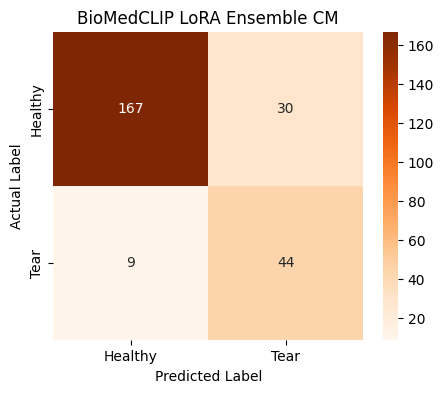

In [ ]:
# ==========================================
# 5: EVALUATION (WEIGHTED ENSEMBLE)
# ==========================================
lora_explain_dicts = {"axial": {}, "coronal": {}, "sagittal": {}}

def extract_lora_probabilities(plane_name, plane_dir, adapter_folder):
    print(f"Extracting LoRA features for {plane_name.upper()}...")

    text_feats = get_ensembled_text_features(plane_name)

    # Load Base vision model + Attached LoRA Adapter
    adapter_path = os.path.join(base_path, adapter_folder)
    lora_vision = PeftModel.from_pretrained(clip_model.visual, adapter_path)

    model = LoRABioMedCLIP(lora_vision, clip_model, text_feats).to(device)
    model.eval()

    dataset = LoRAMRNetDataset(test_df, plane_dir, is_train=False)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    patient_probs, labels = [], []

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device)
            lbl = lbl.item()
            p_id = p_id[0]

            # Forward pass to get Logits
            logits = model(imgs)
            probs = logits.softmax(dim=-1)
            prob_tear = probs[0, 1].cpu().numpy()

            patient_probs.append(prob_tear)
            labels.append(lbl)

            # Store highest prob slice for explainability (like base code)
            # To do this, we compute slice-by-slice probabilities
            img_feats = model.vision_encoder(imgs)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            slice_logits = model.logit_scale.exp() * img_feats @ text_feats.t()
            slice_probs = slice_logits.softmax(dim=-1)[:, 1].cpu().numpy()

            most_suspicious_idx = np.argmax(slice_probs)
            lora_explain_dicts[plane_name][p_id] = most_suspicious_idx

    # Unload adapter to prevent cross-contamination in eval
    clip_model.visual = lora_vision.unload()
    return np.array(patient_probs), np.array(labels)

# 1. Gather LoRA probabilities
s_probs, y_true = extract_lora_probabilities("sagittal", sagittal_dir, "lora_sagittal_best_adapter")
c_probs, _      = extract_lora_probabilities("coronal", coronal_dir, "lora_coronal_best_adapter")
a_probs, _      = extract_lora_probabilities("axial", axial_dir, "lora_axial_best_adapter")

# 2. Radiology-Weighted Fusion
ensemble_probs = (0.6 * s_probs) + (0.3 * c_probs) + (0.1 * a_probs)

# 3. Decision Threshold Calculation
fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\n" + "="*50)
print("LoRA ENSEMBLE RESULTS (Weighted Fusion)")
print("="*50)
print(f"Optimal decision threshold found: {optimal_threshold:.4f}")

final_preds = (ensemble_probs >= optimal_threshold).astype(int)

# Metrics
acc = accuracy_score(y_true, final_preds)
bal_acc = balanced_accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, ensemble_probs)
sens = recall_score(y_true, final_preds)
f1 = f1_score(y_true, final_preds)
tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"AUC:                {auc:.4f}")
print(f"Sensitivity:        {sens:.4f} (Recall for Tears)")
print(f"Specificity:        {spec:.4f} (Recall for Healthy)")
print(f"F1-Score:           {f1:.4f}")

# Heatmap
cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title("BioMedCLIP LoRA Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Visualizing Tear Patient index: 3


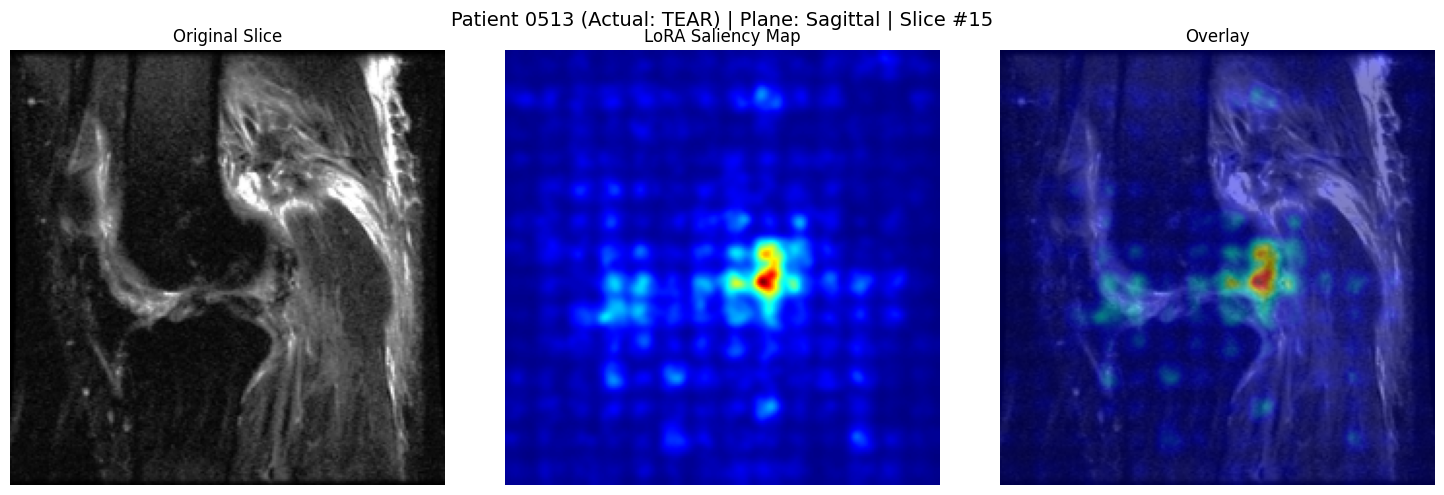

In [ ]:
# ==========================================
# 6: VLM LoRA SALIENCY HEATMAPS
# ==========================================

def generate_lora_saliency_heatmap(img_tensor, plane_name, target_slice_idx, adapter_folder):
    text_feats = get_ensembled_text_features(plane_name)
    tear_feature = text_feats[1:2] # Index 1 is 'Tear'

    # Load Adapter briefly just for inference
    adapter_path = os.path.join(base_path, adapter_folder)
    lora_vision = PeftModel.from_pretrained(clip_model.visual, adapter_path)

    lora_vision.eval()
    lora_vision.zero_grad()

    single_slice = img_tensor[target_slice_idx:target_slice_idx+1].clone().detach().to(device)
    single_slice.requires_grad_()

    # Forward pass
    image_features = lora_vision(single_slice)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    logit_scale = clip_model.logit_scale.exp()
    similarity = (logit_scale * image_features @ tear_feature.t()).squeeze()

    # Backpropagate to extract gradients
    similarity.backward()

    saliency = single_slice.grad.data.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0) # Max over RGB channels

    saliency = cv2.GaussianBlur(saliency, (11, 11), 0)
    if saliency.max() != saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    else:
        saliency = np.zeros_like(saliency)

    heatmap = np.uint8(255 * saliency)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    clip_model.visual = lora_vision.unload()
    return heatmap_color

def visualize_lora_suspicious_slice(patient_idx=0, plane="sagittal"):
    patient_id = str(test_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = test_df.iloc[patient_idx]["label"]

    target_slice_idx = lora_explain_dicts[plane][patient_id]
    plane_dir = sagittal_dir if plane == "sagittal" else (coronal_dir if plane == "coronal" else axial_dir)
    adapter = f"lora_{plane}_best_adapter"

    # Reload Image
    vol = np.load(os.path.join(plane_dir, patient_id + ".npy"))
    ds = LoRAMRNetDataset(test_df, plane_dir, is_train=False)
    img_tensor, _, _ = ds[patient_idx]

    # Generate map
    heatmap_img = generate_lora_saliency_heatmap(img_tensor, plane, target_slice_idx, adapter)

    # Prepare Display
    vol_norm = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)
    slice_img_resized = cv2.resize(vol_norm[target_slice_idx], (224, 224))
    slice_img_255 = (slice_img_resized * 255).astype(np.uint8)
    slice_rgb = np.stack((slice_img_255,)*3, axis=-1)

    overlay = cv2.addWeighted(slice_rgb, 0.5, heatmap_img, 0.5, 0)
    status = "TEAR" if true_label == 1 else "HEALTHY"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Patient {patient_id} (Actual: {status}) | Plane: {plane.capitalize()} | Slice #{target_slice_idx}", fontsize=14)

    axes[0].imshow(slice_img_resized, cmap='gray'); axes[0].set_title("Original Slice"); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)); axes[1].set_title("LoRA Saliency Map"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("Overlay"); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

# Run a visualization on a known positive test case
tear_patients = test_df[test_df['label'] == 1].index.tolist()
if tear_patients:
    print(f"Visualizing Tear Patient index: {tear_patients[0]}")
    visualize_lora_suspicious_slice(patient_idx=tear_patients[0], plane="sagittal")

Extracting LoRA features for SAGITTAL...
Extracting LoRA features for CORONAL...
Extracting LoRA features for AXIAL...

LoRA ENSEMBLE RESULTS (Weighted Fusion)
Optimal decision threshold found: 0.5698
Accuracy:           0.8440
Balanced Accuracy:  0.8390
AUC:                0.8973
Sensitivity:        0.8302 (Recall for Tears)
Specificity:        0.8477 (Recall for Healthy)
F1-Score:           0.6929


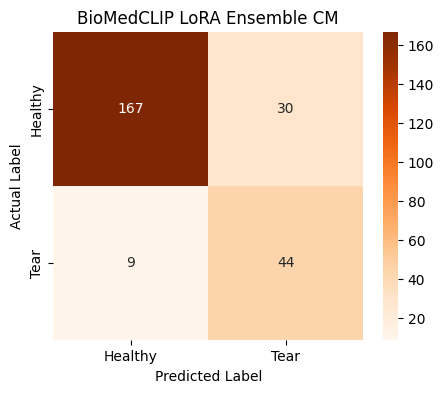

In [ ]:
# ==========================================
# 5: EVALUATION (WEIGHTED ENSEMBLE)
# ==========================================
lora_explain_dicts = {"axial": {}, "coronal": {}, "sagittal": {}}

def extract_lora_probabilities(plane_name, plane_dir, adapter_folder):
    print(f"Extracting LoRA features for {plane_name.upper()}...")

    text_feats = get_ensembled_text_features(plane_name)

     # FIX: Delete the ghost PEFT variable so adapters don't stack
    if hasattr(clip_model.visual, "peft_config"):
        delattr(clip_model.visual, "peft_config")

    # Load Base vision model + Attached LoRA Adapter
    adapter_path = os.path.join(base_path, adapter_folder)
    lora_vision = PeftModel.from_pretrained(clip_model.visual, adapter_path)

    model = LoRABioMedCLIP(lora_vision, clip_model, text_feats).to(device)
    model.eval()

    dataset = LoRAMRNetDataset(test_df, plane_dir, is_train=False)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    patient_probs, labels = [], []

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device)
            lbl = lbl.item()
            p_id = p_id[0]

            # Forward pass to get Logits
            logits = model(imgs)
            probs = logits.softmax(dim=-1)
            prob_tear = probs[0, 1].cpu().numpy()

            patient_probs.append(prob_tear)
            labels.append(lbl)

            # Store highest prob slice for explainability (like base code)
            # To do this, we compute slice-by-slice probabilities
            img_feats = model.vision_encoder(imgs)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            slice_logits = model.logit_scale.exp() * img_feats @ text_feats.t()
            slice_probs = slice_logits.softmax(dim=-1)[:, 1].cpu().numpy()

            most_suspicious_idx = np.argmax(slice_probs)
            lora_explain_dicts[plane_name][p_id] = most_suspicious_idx

    # Unload adapter to prevent cross-contamination in eval
    clip_model.visual = lora_vision.unload()
    return np.array(patient_probs), np.array(labels)

# 1. Gather LoRA probabilities
s_probs, y_true = extract_lora_probabilities("sagittal", sagittal_dir, "lora_sagittal_best_adapter")
c_probs, _      = extract_lora_probabilities("coronal", coronal_dir, "lora_coronal_best_adapter")
a_probs, _      = extract_lora_probabilities("axial", axial_dir, "lora_axial_best_adapter")

# 2. Radiology-Weighted Fusion
ensemble_probs = (0.6 * s_probs) + (0.3 * c_probs) + (0.1 * a_probs)

# 3. Decision Threshold Calculation
fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\n" + "="*50)
print("LoRA ENSEMBLE RESULTS (Weighted Fusion)")
print("="*50)
print(f"Optimal decision threshold found: {optimal_threshold:.4f}")

final_preds = (ensemble_probs >= optimal_threshold).astype(int)

# Metrics
acc = accuracy_score(y_true, final_preds)
bal_acc = balanced_accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, ensemble_probs)
sens = recall_score(y_true, final_preds)
f1 = f1_score(y_true, final_preds)
tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"AUC:                {auc:.4f}")
print(f"Sensitivity:        {sens:.4f} (Recall for Tears)")
print(f"Specificity:        {spec:.4f} (Recall for Healthy)")
print(f"F1-Score:           {f1:.4f}")

# Heatmap
cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title("BioMedCLIP LoRA Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Visualizing Tear Patient index: 3


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


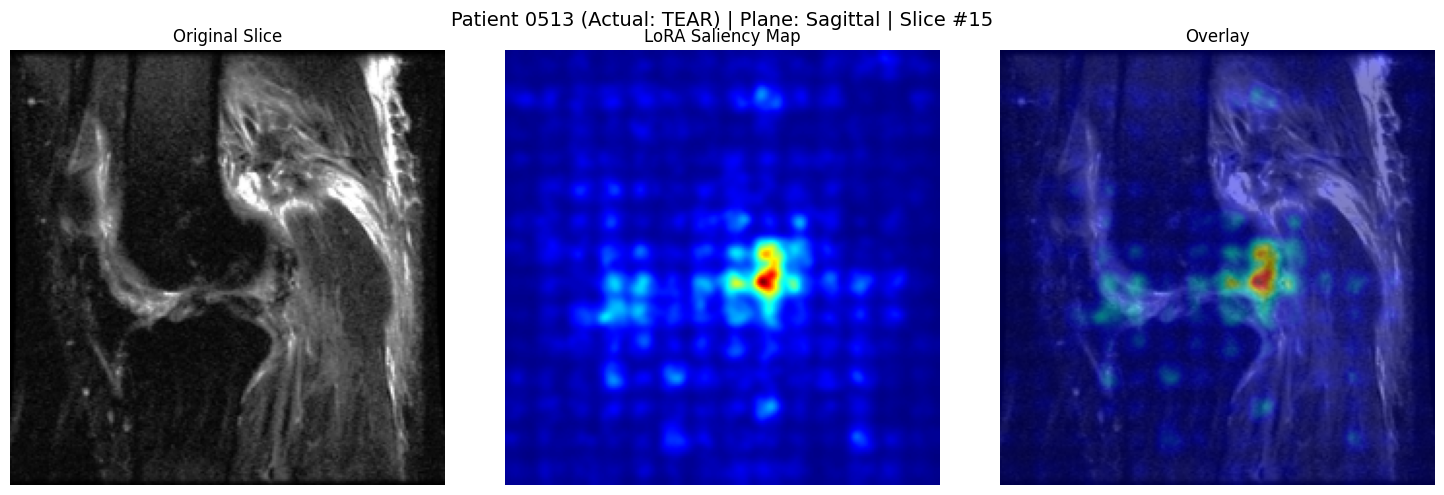

In [ ]:
# ==========================================
# 6: VLM LoRA SALIENCY HEATMAPS
# ==========================================

def generate_lora_saliency_heatmap(img_tensor, plane_name, target_slice_idx, adapter_folder):
    text_feats = get_ensembled_text_features(plane_name)
    tear_feature = text_feats[1:2] # Index 1 is 'Tear'

    # Load Adapter briefly just for inference
    adapter_path = os.path.join(base_path, adapter_folder)
    lora_vision = PeftModel.from_pretrained(clip_model.visual, adapter_path)

    lora_vision.eval()
    lora_vision.zero_grad()

    single_slice = img_tensor[target_slice_idx:target_slice_idx+1].clone().detach().to(device)
    single_slice.requires_grad_()

    # Forward pass
    image_features = lora_vision(single_slice)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    logit_scale = clip_model.logit_scale.exp()
    similarity = (logit_scale * image_features @ tear_feature.t()).squeeze()

    # Backpropagate to extract gradients
    similarity.backward()

    saliency = single_slice.grad.data.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0) # Max over RGB channels

    saliency = cv2.GaussianBlur(saliency, (11, 11), 0)
    if saliency.max() != saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    else:
        saliency = np.zeros_like(saliency)

    heatmap = np.uint8(255 * saliency)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    clip_model.visual = lora_vision.unload()
    return heatmap_color

def visualize_lora_suspicious_slice(patient_idx=0, plane="sagittal"):
    patient_id = str(test_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = test_df.iloc[patient_idx]["label"]

    target_slice_idx = lora_explain_dicts[plane][patient_id]
    plane_dir = sagittal_dir if plane == "sagittal" else (coronal_dir if plane == "coronal" else axial_dir)
    adapter = f"lora_{plane}_best_adapter"

    # Reload Image
    vol = np.load(os.path.join(plane_dir, patient_id + ".npy"))
    ds = LoRAMRNetDataset(test_df, plane_dir, is_train=False)
    img_tensor, _, _ = ds[patient_idx]

    # Generate map
    heatmap_img = generate_lora_saliency_heatmap(img_tensor, plane, target_slice_idx, adapter)

    # Prepare Display
    vol_norm = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)
    slice_img_resized = cv2.resize(vol_norm[target_slice_idx], (224, 224))
    slice_img_255 = (slice_img_resized * 255).astype(np.uint8)
    slice_rgb = np.stack((slice_img_255,)*3, axis=-1)

    overlay = cv2.addWeighted(slice_rgb, 0.5, heatmap_img, 0.5, 0)
    status = "TEAR" if true_label == 1 else "HEALTHY"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Patient {patient_id} (Actual: {status}) | Plane: {plane.capitalize()} | Slice #{target_slice_idx}", fontsize=14)

    axes[0].imshow(slice_img_resized, cmap='gray'); axes[0].set_title("Original Slice"); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)); axes[1].set_title("LoRA Saliency Map"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("Overlay"); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

# Run a visualization on a known positive test case
tear_patients = test_df[test_df['label'] == 1].index.tolist()
if tear_patients:
    print(f"Visualizing Tear Patient index: {tear_patients[0]}")
    visualize_lora_suspicious_slice(patient_idx=tear_patients[0], plane="sagittal")